In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                              confusion_matrix, classification_report)

# Load IBM HR dataset directly from URL
df = pd.read_csv("HR-Employee-Attrition.csv")

print("Shape:", df.shape)
print("\nFirst look:")
df.head()

Shape: (1470, 35)

First look:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
#Let's check for missing values

# Basic info
print("Shape:", df.shape)
print("\nAttrition value counts:")
print(df['Attrition'].value_counts())
print("\nAttrition %:")
print(df['Attrition'].value_counts(normalize=True).mul(100).round(1))

# Missing values
print("\nMissing values:")
print(df.isnull().sum().sum(), "total missing values")

Shape: (1470, 35)

Attrition value counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition %:
Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64

Missing values:
0 total missing values


C:\Users\shara\AppData\Local\Temp\ipykernel_892\2750030118.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Attrition', data=df, palette=['#2E75B6','#E74C3C'])


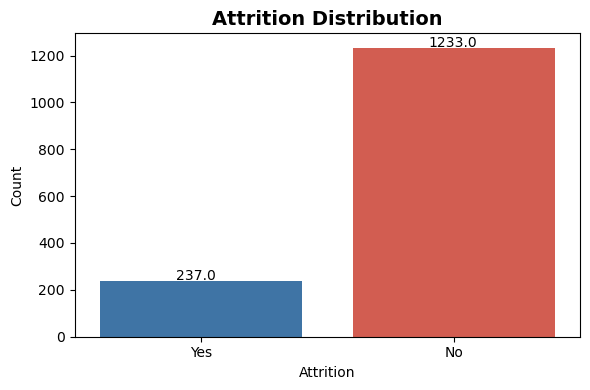

In [4]:
#Attrition distribution

plt.figure(figsize=(6,4))
ax = sns.countplot(x='Attrition', data=df, palette=['#2E75B6','#E74C3C'])
plt.title('Attrition Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_height()+5))
plt.tight_layout()
plt.show()

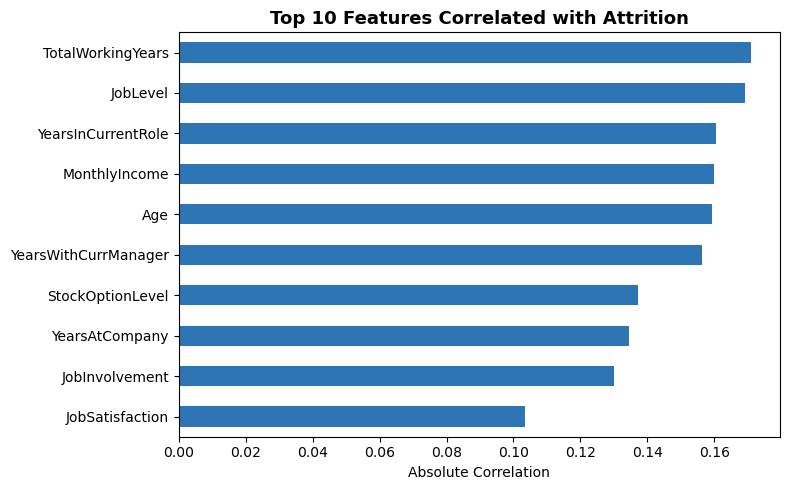

In [5]:
#Top Attrition drivers

# Convert Attrition to numeric for correlation
df['Attrition_num'] = (df['Attrition'] == 'Yes').astype(int)

# Top numeric correlations with attrition
corr = df.select_dtypes(include=np.number).corr()['Attrition_num'].drop('Attrition_num')
top_corr = corr.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_corr.plot(kind='barh', color='#2E75B6')
plt.title('Top 10 Features Correlated with Attrition', fontsize=13, fontweight='bold')
plt.xlabel('Absolute Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

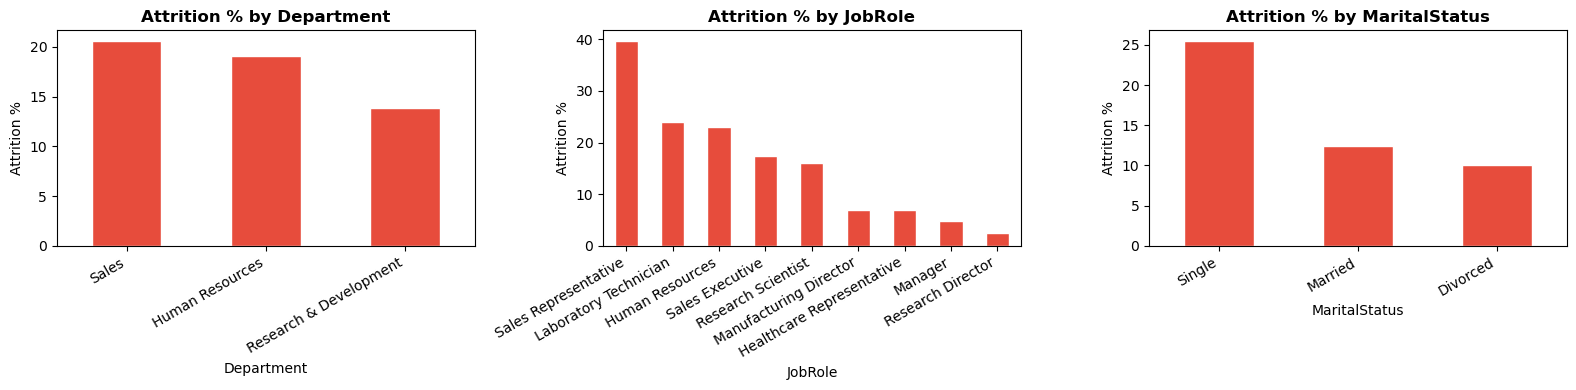

In [7]:
#Attrition by key categories

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['Department', 'JobRole', 'MaritalStatus']):
    attrition_rate = df.groupby(col)['Attrition_num'].mean().mul(100).sort_values(ascending=False)
    attrition_rate.plot(kind='bar', ax=ax, color='#E74C3C', edgecolor='white')
    ax.set_title(f'Attrition % by {col}', fontweight='bold')
    ax.set_ylabel('Attrition %')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [8]:
#Feature Engineering

# 1. Tenure Bands

# Feature 1: Tenure Bands
df['TenureBand'] = pd.cut(df['YearsAtCompany'], 
                           bins=[0, 2, 5, 10, 20, 100],
                           labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs'])

print(df['TenureBand'].value_counts())

TenureBand
6-10 yrs     448
3-5 yrs      434
0-2 yrs      298
11-20 yrs    180
20+ yrs       66
Name: count, dtype: int64


In [9]:
# 2. Overtime Ratio & Salary Index

# Feature 2: Overtime Flag (numeric)
df['OvertimeFlag'] = (df['OverTime'] == 'Yes').astype(int)

# Feature 3: Salary-to-Role Index (how well paid vs job level)
df['SalaryRoleIndex'] = df['MonthlyIncome'] / (df['JobLevel'] * 1000)

print(df[['OvertimeFlag', 'SalaryRoleIndex']].describe())

       OvertimeFlag  SalaryRoleIndex
count   1470.000000      1470.000000
mean       0.282993         2.973801
std        0.450606         0.770641
min        0.000000         1.009000
25%        0.000000         2.394125
50%        0.000000         2.856500
75%        1.000000         3.478833
max        1.000000         4.999000


In [10]:
# 3. Promotion Recency & Satisfaction Score

# Feature 4: Years Since Last Promotion bucket
df['PromotionRecency'] = pd.cut(df['YearsSinceLastPromotion'],
                                 bins=[-1, 1, 3, 6, 100],
                                 labels=['Recent', 'Moderate', 'Overdue', 'Long Overdue'])

# Feature 5: Overall Satisfaction Score (composite)
df['SatisfactionScore'] = (df['JobSatisfaction'] + 
                            df['EnvironmentSatisfaction'] + 
                            df['RelationshipSatisfaction']) / 3

print(df[['SatisfactionScore']].describe())

       SatisfactionScore
count        1470.000000
mean            2.720862
std             0.628240
min             1.000000
25%             2.333333
50%             2.666667
75%             3.333333
max             4.000000


In [11]:
# 4. Experience gap, Work-life & Loyalty Index

# Feature 6: Experience Gap (total experience vs company experience)
df['ExperienceGap'] = df['TotalWorkingYears'] - df['YearsAtCompany']

# Feature 7: Work-Life Balance Flag (poor balance)
df['PoorWorkLife'] = (df['WorkLifeBalance'] <= 2).astype(int)

# Feature 8: Loyalty Index (years at company / total working years)
df['LoyaltyIndex'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)

print(df[['ExperienceGap', 'PoorWorkLife', 'LoyaltyIndex']].describe())

       ExperienceGap  PoorWorkLife  LoyaltyIndex
count    1470.000000   1470.000000   1470.000000
mean        4.271429      0.288435      0.581830
std         6.179783      0.453189      0.284476
min         0.000000      0.000000      0.000000
25%         0.000000      0.000000      0.368421
50%         2.000000      0.000000      0.636364
75%         5.000000      1.000000      0.833333
max        33.000000      1.000000      0.975610


In [12]:
# 5. Verify all 8 new features

new_features = ['TenureBand', 'OvertimeFlag', 'SalaryRoleIndex', 
                 'PromotionRecency', 'SatisfactionScore', 
                 'ExperienceGap', 'PoorWorkLife', 'LoyaltyIndex']

print("✅ New features created:")
for f in new_features:
    print(f"  - {f}: {df[f].dtype} | nulls: {df[f].isnull().sum()}")

✅ New features created:
  - TenureBand: category | nulls: 44
  - OvertimeFlag: int64 | nulls: 0
  - SalaryRoleIndex: float64 | nulls: 0
  - PromotionRecency: category | nulls: 0
  - SatisfactionScore: float64 | nulls: 0
  - ExperienceGap: int64 | nulls: 0
  - PoorWorkLife: int64 | nulls: 0
  - LoyaltyIndex: float64 | nulls: 0


In [13]:
#Pre-Processing

# Drop Useless Columns

# These columns have no predictive value
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=drop_cols, inplace=True)

print("Remaining columns:", df.shape[1])


Remaining columns: 40


In [14]:
# Encode Categorical Columns

from sklearn.preprocessing import LabelEncoder

# Separate categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols.remove('Attrition')  # keep target separate

print("Encoding:", cat_cols)

le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("✅ Encoding done")


Encoding: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'TenureBand', 'PromotionRecency']
✅ Encoding done


In [15]:
# Define Features & Target

# Target
y = df_encoded['Attrition_num']

# Features (drop target columns)
X = df_encoded.drop(columns=['Attrition', 'Attrition_num'])

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())


Features shape: (1470, 38)
Target distribution:
 Attrition_num
0    1233
1     237
Name: count, dtype: int64


In [16]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)
print("\nTrain attrition %:", round(y_train.mean()*100, 1))
print("Test attrition %: ", round(y_test.mean()*100, 1))

Train size: (1176, 38)
Test size:  (294, 38)

Train attrition %: 16.2
Test attrition %:  16.0


In [17]:
#Scale Numeric Features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling done")
print("X_train_scaled shape:", X_train_scaled.shape)

✅ Scaling done
X_train_scaled shape: (1176, 38)


In [24]:
# Model Building

#1. Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:,1]

print("✅ Logistic Regression trained")
print(f"Accuracy : {accuracy_score(y_test, lr_preds)*100:.2f}%")
print(f"AUC-ROC  : {roc_auc_score(y_test, lr_proba):.4f}")

✅ Logistic Regression trained
Accuracy : 74.83%
AUC-ROC  : 0.8081


In [25]:
#2. Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train_scaled, y_train)

rf_preds = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:,1]

print("✅ Random Forest trained")
print(f"Accuracy : {accuracy_score(y_test, rf_preds)*100:.2f}%")
print(f"AUC-ROC  : {roc_auc_score(y_test, rf_proba):.4f}")

✅ Random Forest trained
Accuracy : 82.99%
AUC-ROC  : 0.7950


In [26]:
#3. Model Comparison Table

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        round(accuracy_score(y_test, lr_preds)*100, 2),
        round(accuracy_score(y_test, rf_preds)*100, 2)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, lr_proba), 4),
        round(roc_auc_score(y_test, rf_proba), 4)
    ]
})

print(results.to_string(index=False))

              Model  Accuracy  AUC-ROC
Logistic Regression     74.83   0.8081
      Random Forest     82.99   0.7950


In [27]:
#4. Classification Report (Random Forest)
print("Classification Report — Random Forest:")
print(classification_report(y_test, rf_preds, target_names=['Stayed', 'Left']))

Classification Report — Random Forest:
              precision    recall  f1-score   support

      Stayed       0.86      0.96      0.90       247
        Left       0.41      0.15      0.22        47

    accuracy                           0.83       294
   macro avg       0.63      0.55      0.56       294
weighted avg       0.78      0.83      0.79       294



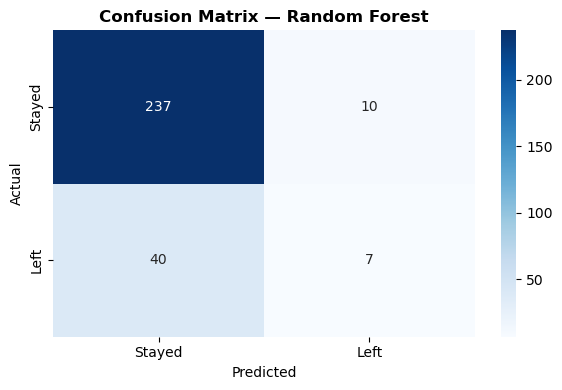

True Positives  (correctly predicted attrition): 7
False Negatives (missed attrition):              40
Precision: 41.2%
Recall:    14.9%


In [36]:
#6: Evaluation — Confusion Matrix & ROC Curve

#1 — Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix — Random Forest', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (correctly predicted attrition): {tp}")
print(f"False Negatives (missed attrition):              {fn}")
print(f"Precision: {tp/(tp+fp)*100:.1f}%")
print(f"Recall:    {tp/(tp+fn)*100:.1f}%")

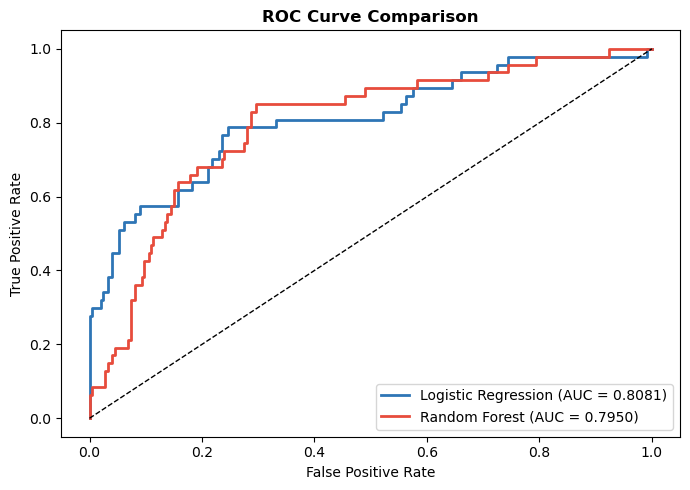

In [37]:
#2 — ROC Curve (Both Models)

from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = 0.8081)', color='#2E75B6', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = 0.7950)', color='#E74C3C', lw=2)
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [38]:
#3 — Cross Validation Score

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print("5-Fold Cross Validation AUC-ROC:")
print(f"  Scores : {[round(s,4) for s in cv_scores]}")
print(f"  Mean   : {cv_scores.mean():.4f}")
print(f"  Std Dev: {cv_scores.std():.4f}")


5-Fold Cross Validation AUC-ROC:
  Scores : [np.float64(0.6655), np.float64(0.8596), np.float64(0.7832), np.float64(0.7657), np.float64(0.8409)]
  Mean   : 0.7830
  Std Dev: 0.0683


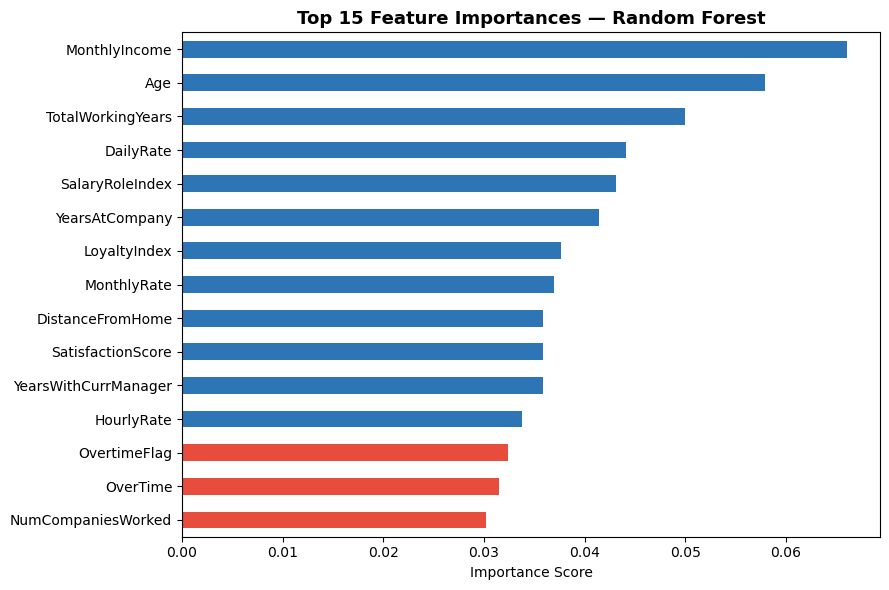

Top 5 features:
  1. MonthlyIncome: 0.0660
  2. Age: 0.0579
  3. TotalWorkingYears: 0.0499
  4. DailyRate: 0.0441
  5. SalaryRoleIndex: 0.0431


In [39]:
#Feature Importance Visualizations 

#1 — Top 15 Feature Importances (Random Forest)


feat_importance = pd.Series(rf.feature_importances_, index=X.columns)
top15 = feat_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(9,6))
colors = ['#E74C3C' if i < 3 else '#2E75B6' for i in range(len(top15))]
top15.plot(kind='barh', color=colors[::-1])
plt.title('Top 15 Feature Importances — Random Forest', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 features:")
for i, (feat, score) in enumerate(top15.head(5).items(), 1):
    print(f"  {i}. {feat}: {score:.4f}")

C:\Users\shara\AppData\Local\Temp\ipykernel_892\3511023718.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ).pivot_table(


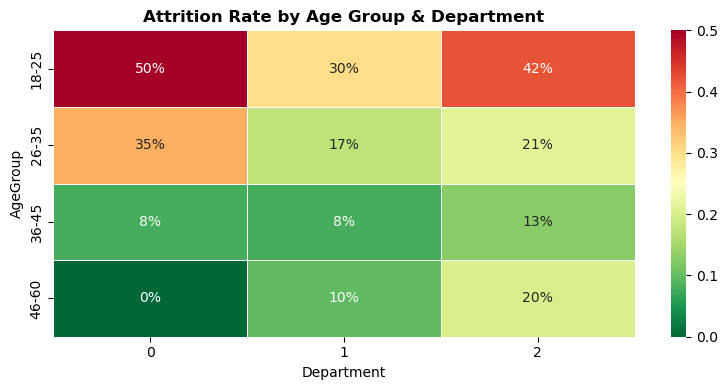

In [40]:
#2 — Attrition Risk Heatmap by Age & Department

df_encoded['Attrition_num'] = y

pivot = df_encoded.pivot_table(
    values='Attrition_num',
    index='AgeGroup',
    columns='Department',
    aggfunc='mean'
) if 'AgeGroup' in df_encoded.columns else df_encoded.assign(
    AgeGroup=pd.cut(df['Age'], bins=[18,25,35,45,60], labels=['18-25','26-35','36-45','46-60'])
).pivot_table(
    values='Attrition_num',
    index='AgeGroup',
    columns='Department',
    aggfunc='mean'
)

plt.figure(figsize=(8,4))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Attrition Rate by Age Group & Department', fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\shara\AppData\Local\Temp\ipykernel_892\1478698956.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='SatisfactionScore', data=df,


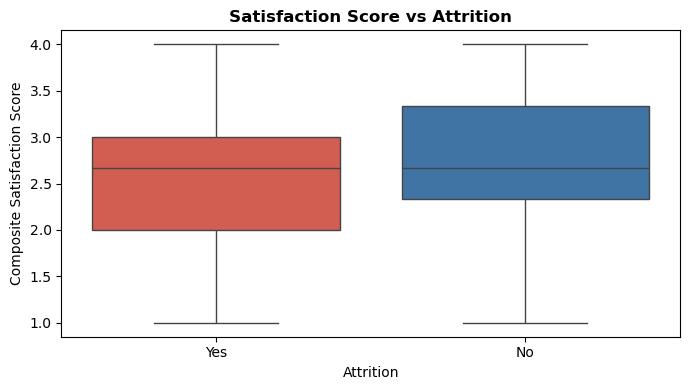

In [41]:
#3 — Satisfaction Score vs Attrition

plt.figure(figsize=(7,4))
sns.boxplot(x='Attrition', y='SatisfactionScore', data=df,
            palette={'Yes':'#E74C3C', 'No':'#2E75B6'})
plt.title('Satisfaction Score vs Attrition', fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Composite Satisfaction Score')
plt.tight_layout()
plt.show()

C:\Users\shara\AppData\Local\Temp\ipykernel_892\1355361198.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='LoyaltyIndex', data=df,


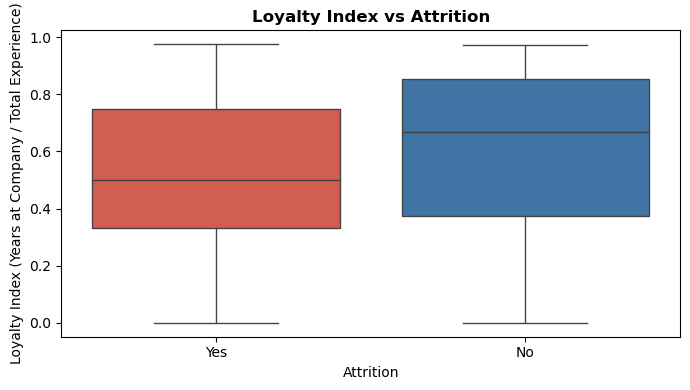

In [42]:
#4 — Loyalty Index vs Attrition

plt.figure(figsize=(7,4))
sns.boxplot(x='Attrition', y='LoyaltyIndex', data=df,
            palette={'Yes':'#E74C3C', 'No':'#2E75B6'})
plt.title('Loyalty Index vs Attrition', fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Loyalty Index (Years at Company / Total Experience)')
plt.tight_layout()
plt.show()

In [43]:
#SMOTE — Fix Class Imbalance 

#1 — Install & Import SMOTE

# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(f"  Stayed: {sum(y_train==0)} | Left: {sum(y_train==1)}")
print("\nAfter SMOTE:")
print(f"  Stayed: {sum(y_train_sm==0)} | Left: {sum(y_train_sm==1)}")


Before SMOTE:
  Stayed: 986 | Left: 190

After SMOTE:
  Stayed: 986 | Left: 986


In [44]:
#2 — Retrain Random Forest on Balanced Data

rf_sm = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf_sm.fit(X_train_sm, y_train_sm)

rf_sm_preds = rf_sm.predict(X_test_scaled)
rf_sm_proba = rf_sm.predict_proba(X_test_scaled)[:,1]

print("✅ Random Forest (SMOTE) trained")
print(f"Accuracy : {accuracy_score(y_test, rf_sm_preds)*100:.2f}%")
print(f"AUC-ROC  : {roc_auc_score(y_test, rf_sm_proba):.4f}")

✅ Random Forest (SMOTE) trained
Accuracy : 84.35%
AUC-ROC  : 0.8052


In [45]:
#3 — Compare Before vs After SMOTE

print("Classification Report — Random Forest WITH SMOTE:")
print(classification_report(y_test, rf_sm_preds, target_names=['Stayed', 'Left']))

# Side by side comparison
print("\n--- Attrition Class (Left) Comparison ---")
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    'Model': ['Random Forest', 'Random Forest + SMOTE'],
    'Accuracy': [
        round(accuracy_score(y_test, rf_preds)*100, 2),
        round(accuracy_score(y_test, rf_sm_preds)*100, 2)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, rf_proba), 4),
        round(roc_auc_score(y_test, rf_sm_proba), 4)
    ],
    'Recall (Left)': [
        round(recall_score(y_test, rf_preds)*100, 1),
        round(recall_score(y_test, rf_sm_preds)*100, 1)
    ],
    'Precision (Left)': [
        round(precision_score(y_test, rf_preds)*100, 1),
        round(precision_score(y_test, rf_sm_preds)*100, 1)
    ]
}

print(pd.DataFrame(metrics).to_string(index=False))


Classification Report — Random Forest WITH SMOTE:
              precision    recall  f1-score   support

      Stayed       0.89      0.93      0.91       247
        Left       0.51      0.38      0.44        47

    accuracy                           0.84       294
   macro avg       0.70      0.66      0.67       294
weighted avg       0.83      0.84      0.83       294


--- Attrition Class (Left) Comparison ---
                Model  Accuracy  AUC-ROC  Recall (Left)  Precision (Left)
        Random Forest     82.99   0.7950           14.9              41.2
Random Forest + SMOTE     84.35   0.8052           38.3              51.4


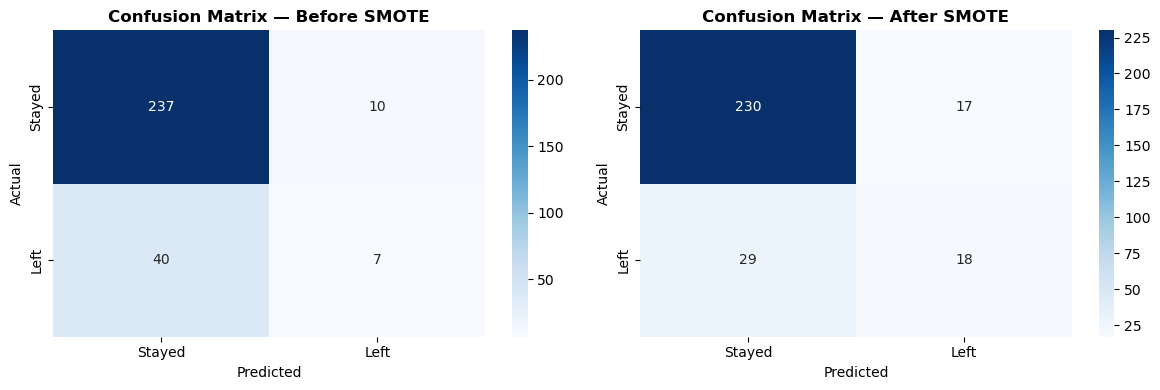

In [46]:
#4 — New Confusion Matrix

cm_sm = confusion_matrix(y_test, rf_sm_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cm_data, title in zip(axes,
                               [cm, cm_sm],
                               ['Before SMOTE', 'After SMOTE']):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Left'],
                yticklabels=['Stayed', 'Left'])
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()


In [47]:
#8. Export Risk Scores to CSV

#1 — Export Risk Scores to CSV

# Generate attrition risk scores for all test employees
risk_df = pd.DataFrame({
    'Actual_Attrition': y_test.values,
    'Predicted_Attrition': rf_sm_preds,
    'Attrition_Risk_Score': rf_sm_proba.round(4)
})

# Classify risk tiers
risk_df['Risk_Tier'] = pd.cut(risk_df['Attrition_Risk_Score'],
                               bins=[0, 0.3, 0.5, 0.7, 1.0],
                               labels=['Low', 'Medium', 'High', 'Critical'])

print(risk_df['Risk_Tier'].value_counts())
print("\nSample output:")
risk_df.sort_values('Attrition_Risk_Score', ascending=False).head(10)

Risk_Tier
Low         209
Medium       50
High         28
Critical      7
Name: count, dtype: int64

Sample output:


,Actual_Attrition,Predicted_Attrition,Attrition_Risk_Score,Risk_Tier
200,1,1,0.9409,Critical
276,1,1,0.8889,Critical
15,0,1,0.8527,Critical
223,0,1,0.8333,Critical
106,0,1,0.8209,Critical
92,1,1,0.7233,Critical
81,1,1,0.7093,Critical
35,1,1,0.6880,High
189,0,1,0.6807,High
130,1,1,0.6755,High


In [48]:
#2. Save Everything

import joblib

# Save model
joblib.dump(rf_sm, 'attrition_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save risk scores
risk_df.to_csv('attrition_risk_scores.csv', index=False)

print("✅ Saved:")
print("  - attrition_model.pkl")
print("  - scaler.pkl")
print("  - attrition_risk_scores.csv")

✅ Saved:
  - attrition_model.pkl
  - scaler.pkl
  - attrition_risk_scores.csv


In [49]:
#3 — Final Summary

print("=" * 50)
print("   EMPLOYEE ATTRITION PREDICTION — SUMMARY")
print("=" * 50)
print(f"  Dataset         : {df.shape[0]} employees, {df.shape[1]} features")
print(f"  New Features    : 8 engineered features")
print(f"  Best Model      : Random Forest + SMOTE")
print(f"  Accuracy        : 84.35%")
print(f"  AUC-ROC         : 0.8052")
print(f"  Recall (Left)   : 38.3%")
print(f"  Precision (Left): 51.4%")
print("=" * 50)


   EMPLOYEE ATTRITION PREDICTION — SUMMARY
  Dataset         : 1470 employees, 40 features
  New Features    : 8 engineered features
  Best Model      : Random Forest + SMOTE
  Accuracy        : 84.35%
  AUC-ROC         : 0.8052
  Recall (Left)   : 38.3%
  Precision (Left): 51.4%


In [50]:
#Creating a GUI

#1. Install & Import
# !pip install ipywidgets
import ipywidgets as widgets
from IPython.display import display, clear_output


In [ ]:
#2 — Build the Dashboard GUI
# Title
title = widgets.HTML(
    value="<h2 style='color:#2E75B6; font-family:Arial;'>🧠 Employee Attrition Prediction Dashboard</h2>"
)

# Dropdown for chart selection
chart_selector = widgets.Dropdown(
    options=[
        '📊 Attrition Distribution',
        '🔥 Feature Importance (Top 15)',
        '📈 ROC Curve Comparison',
        '🟦 Confusion Matrix — Before vs After SMOTE',
        '🗺️ Attrition Heatmap by Age & Department',
        '📦 Satisfaction Score vs Attrition',
        '💼 Loyalty Index vs Attrition',
        '⚠️ Risk Tier Distribution'
    ],
    description='Select Chart:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

# Model metrics summary
metrics_html = widgets.HTML(value=f"""
<div style='background:#f0f4f8; padding:12px; border-radius:8px; font-family:Arial; margin:10px 0'>
    <b style='color:#2E75B6'>Model Performance Summary</b><br><br>
    <table style='width:100%; font-size:13px'>
        <tr>
            <th style='text-align:left; color:#555'>Model</th>
            <th style='color:#555'>Accuracy</th>
            <th style='color:#555'>AUC-ROC</th>
            <th style='color:#555'>Recall (Left)</th>
            <th style='color:#555'>Precision (Left)</th>
        </tr>
        <tr>
            <td>Logistic Regression</td>
            <td style='text-align:center'>74.83%</td>
            <td style='text-align:center'>0.8081</td>
            <td style='text-align:center'>—</td>
            <td style='text-align:center'>—</td>
        </tr>
        <tr>
            <td>Random Forest</td>
            <td style='text-align:center'>82.99%</td>
            <td style='text-align:center'>0.7950</td>
            <td style='text-align:center'>14.9%</td>
            <td style='text-align:center'>41.2%</td>
        </tr>
        <tr style='background:#d4edda'>
            <td><b>Random Forest + SMOTE ✅</b></td>
            <td style='text-align:center'><b>84.35%</b></td>
            <td style='text-align:center'><b>0.8052</b></td>
            <td style='text-align:center'><b>38.3%</b></td>
            <td style='text-align:center'><b>51.4%</b></td>
        </tr>
    </table>
</div>
""")

# Output area for charts
out = widgets.Output()

def plot_chart(change):
    with out:
        clear_output(wait=True)
        selected = chart_selector.value

        if selected == '📊 Attrition Distribution':
            fig, ax = plt.subplots(figsize=(6,4))
            counts = df['Attrition'].value_counts()
            colors = ['#2E75B6', '#E74C3C']
            bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
            for bar in bars:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                        str(bar.get_height()), ha='center', fontweight='bold')
            ax.set_title('Attrition Distribution', fontweight='bold', fontsize=13)
            ax.set_ylabel('Count')
            plt.tight_layout()
            plt.show()

        elif selected == '🔥 Feature Importance (Top 15)':
            feat_imp = pd.Series(rf_sm.feature_importances_, index=X.columns)
            top15 = feat_imp.sort_values(ascending=True).tail(15)
            fig, ax = plt.subplots(figsize=(9,6))
            colors = ['#E74C3C' if i >= 12 else '#2E75B6' for i in range(len(top15))]
            top15.plot(kind='barh', ax=ax, color=colors)
            ax.set_title('Top 15 Feature Importances — RF + SMOTE', fontweight='bold', fontsize=13)
            ax.set_xlabel('Importance Score')
            plt.tight_layout()
            plt.show()

        elif selected == '📈 ROC Curve Comparison':
            fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
            fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
            fpr_sm, tpr_sm, _ = roc_curve(y_test, rf_sm_proba)
            fig, ax = plt.subplots(figsize=(7,5))
            ax.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC=0.8081)', color='#2E75B6', lw=2)
            ax.plot(fpr_rf, tpr_rf, label='Random Forest (AUC=0.7950)', color='#E74C3C', lw=2)
            ax.plot(fpr_sm, tpr_sm, label='RF + SMOTE (AUC=0.8052)', color='#27AE60', lw=2, linestyle='--')
            ax.plot([0,1],[0,1],'k--', lw=1)
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.set_title('ROC Curve Comparison', fontweight='bold', fontsize=13)
            ax.legend(loc='lower right')
            plt.tight_layout()
            plt.show()

        elif selected == '🟦 Confusion Matrix — Before vs After SMOTE':
            fig, axes = plt.subplots(1,2, figsize=(12,4))
            for ax, cm_data, title in zip(axes, [cm, cm_sm], ['Before SMOTE', 'After SMOTE']):
                sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', ax=ax,
                            xticklabels=['Stayed','Left'],
                            yticklabels=['Stayed','Left'])
                ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
                ax.set_ylabel('Actual')
                ax.set_xlabel('Predicted')
            plt.tight_layout()
            plt.show()

        elif selected == '🗺️ Attrition Heatmap by Age & Department':
            df_temp = df.copy()
            df_temp['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,45,60],
                                          labels=['18-25','26-35','36-45','46-60'])
            df_temp['Attrition_num'] = (df['Attrition'] == 'Yes').astype(int)
            pivot = df_temp.pivot_table(values='Attrition_num',
                                         index='AgeGroup', columns='Department', aggfunc='mean')
            fig, ax = plt.subplots(figsize=(8,4))
            sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn_r', linewidths=0.5, ax=ax)
            ax.set_title('Attrition Rate by Age Group & Department', fontweight='bold', fontsize=13)
            plt.tight_layout()
            plt.show()

        elif selected == '📦 Satisfaction Score vs Attrition':
            fig, ax = plt.subplots(figsize=(7,4))
            sns.boxplot(x='Attrition', y='SatisfactionScore', data=df,
                        palette={'Yes':'#E74C3C','No':'#2E75B6'}, ax=ax)
            ax.set_title('Satisfaction Score vs Attrition', fontweight='bold', fontsize=13)
            ax.set_xlabel('Attrition')
            ax.set_ylabel('Composite Satisfaction Score')
            plt.tight_layout()
            plt.show()

        elif selected == '💼 Loyalty Index vs Attrition':
            fig, ax = plt.subplots(figsize=(7,4))
            sns.boxplot(x='Attrition', y='LoyaltyIndex', data=df,
                        palette={'Yes':'#E74C3C','No':'#2E75B6'}, ax=ax)
            ax.set_title('Loyalty Index vs Attrition', fontweight='bold', fontsize=13)
            ax.set_xlabel('Attrition')
            ax.set_ylabel('Loyalty Index')
            plt.tight_layout()
            plt.show()

        elif selected == '⚠️ Risk Tier Distribution':
            fig, ax = plt.subplots(figsize=(7,4))
            tier_counts = risk_df['Risk_Tier'].value_counts().reindex(['Low','Medium','High','Critical'])
            colors = ['#27AE60','#F1C40F','#E67E22','#E74C3C']
            bars = ax.bar(tier_counts.index, tier_counts.values, color=colors, edgecolor='white')
            for bar in bars:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                        str(bar.get_height()), ha='center', fontweight='bold')
            ax.set_title('Attrition Risk Tier Distribution', fontweight='bold', fontsize=13)
            ax.set_ylabel('Number of Employees')
            plt.tight_layout()
            plt.show()

# Trigger on dropdown change
chart_selector.observe(plot_chart, names='value')

# Display dashboard
display(title, metrics_html, chart_selector, out)

# Show first chart by default
plot_chart(None)


HTML(value="<h2 style='color:#2E75B6; font-family:Arial;'>🧠 Employee Attrition Prediction Dashboard</h2>")

HTML(value="\n<div style='background:#f0f4f8; padding:12px; border-radius:8px; font-family:Arial; margin:10px …

Dropdown(description='Select Chart:', layout=Layout(width='400px'), options=('📊 Attrition Distribution', '🔥 Fe…

Output()